# 09 — HMM dynamics for one asset

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mamadouyamar/CVineMarketGen/blob/main/examples/09_hmm_dynamics.ipynb)

A Gaussian hidden Markov model puts each day in one of a few regimes, each
with its own mean and volatility, and lets a Markov chain switch between them.
As a dynamics model its residual layer is the Rosenblatt uniform
`v_t = F_t(y_t)`, the predictive mixture evaluated at the observed return,
which is i.i.d. uniform when the model is right; the package takes its normal
score so the C-vine sees the same kind of residual as for a GARCH. A
parametric-bootstrap Cramér-von Mises test on these uniforms is the
goodness-of-fit check, as in GenHMM1d.

Runtime: about 1.5 hours, nearly all of it in the three bootstraps of 100 refits.

## Import

In [1]:
import os, sys, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
pd.set_option("display.width", 160)

ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "examples" else os.getcwd()
sys.path.insert(0, ROOT)                 # run from a local clone, from examples/ or the root
try:
    import cvinemarketgen                # local clone or already installed
except ImportError:                      # e.g. on Google Colab
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "git+https://github.com/mamadouyamar/CVineMarketGen.git[garch]"], check=True)
    import cvinemarketgen
print("cvinemarketgen", cvinemarketgen.__version__)

from cvinemarketgen import GaussianHMM, load_daily_returns, iid_tests, gof_bootstrap, select_dynamics

cvinemarketgen 0.3.0


## Daily returns of long Treasuries

TLT since 2010, from the cache of notebook 07. The series is the simple daily return $r_t = P_t / P_{t-1} - 1$ of the adjusted close, $t = 1, \dots, n$ with $n = 4{,}197$ days. The table gives the sample moments: mean $\bar r = \frac{1}{n}\sum_t r_t$, standard deviation $\hat\sigma = \big(\frac{1}{n-1}\sum_t (r_t - \bar r)^2\big)^{1/2}$ and the quantiles. Daily returns are in decimals; the annualized figures below multiply the mean by 252 and the volatility by $\sqrt{252}$.

In [2]:
daily = load_daily_returns(["SPY", "TLT", "GLD", "DBC"], start="2010-01-01", cache=os.path.join(ROOT, "data", "daily_cache.csv"))
y = daily["TLT"]
y.describe().round(4)

daily returns read from cache /Users/mamadouthioub/Desktop/CopulaGenerator/CVineMarketGen/data/daily_cache.csv: 4197 days, 2010-01-05 to 2026-09-11


count    4197.0000
mean        0.0001
std         0.0094
min        -0.0667
25%        -0.0056
50%         0.0005
75%         0.0057
max         0.0752
Name: TLT, dtype: float64

## Fit two and three regimes

The Gaussian hidden Markov model has a regime $S_t \in \{1, \dots, K\}$ that follows a Markov chain with transition matrix $Q$, $Q_{jk} = \Pr(S_t = k \mid S_{t-1} = j)$, and a return that is normal within the regime,

$$
r_t \mid S_t = k \;\sim\; N(\mu_k, \sigma_k^2).
$$

The parameters $(\mu_k, \sigma_k)_{k=1}^K$ and $Q$ are estimated by the EM algorithm of GenHMM1d (`EstHMMGen`), started from a split of the sample at its empirical percentiles, with the log-likelihood

$$
\ell = \sum_{t=1}^{n} \log \sum_{k=1}^{K} \eta_{t|t-1,k}\, \phi\!\left(\frac{r_t - \mu_k}{\sigma_k}\right) \frac{1}{\sigma_k},
$$

where $\eta_{t|t-1,k} = \Pr(S_t = k \mid r_{1:t-1})$ is the predictive probability of regime $k$ and $\phi$ the standard normal density. The number of free parameters is $K(K-1)$ for $Q$ plus $2K$ for the means and volatilities, and $\mathrm{BIC} = k \ln n - 2\ell$. States are sorted by mean, so state 1 is the lowest-mean regime. The table shows $252\,\mu_k$, $\sqrt{252}\,\sigma_k$ and the diagonal $Q_{kk}$, the probability of staying in regime $k$ from one day to the next; the expected duration of a visit to regime $k$ is $1 / (1 - Q_{kk})$ days.

In [3]:
t0 = time.time()
m2 = GaussianHMM(2).fit(y)
m3 = GaussianHMM(3).fit(y)
print(f"fit: {time.time() - t0:.0f} s")

def regimes_table(m):
    return pd.DataFrame({"mean (ann.)": m.mu * 252, "vol (ann.)": m.sigma * np.sqrt(252), "stay prob.": np.diag(m.Q)},
                        index=[f"state {k + 1}" for k in range(m.K)]).round(3)

print(m2.name, f"loglik {m2.loglik:.1f}, BIC {m2.bic:.1f}")
regimes_table(m2)

fit: 58 s
HMM(2) loglik 13918.9, BIC -27787.7


,mean (ann.),vol (ann.),stay prob.
state 1,-0.007,0.210,0.979
state 2,0.053,0.112,0.991


The same estimation with $K = 3$: $3 \cdot 2 + 2 \cdot 3 = 12$ parameters against 6. Compare the two models by BIC, $\mathrm{BIC} = k \ln n - 2\ell$, which is lower for the better model; the log-likelihood always rises with $K$, the penalty $k \ln n$ decides whether the third regime is worth its six extra parameters.

In [4]:
print(m3.name, f"loglik {m3.loglik:.1f}, BIC {m3.bic:.1f}")
regimes_table(m3)

HMM(3) loglik 13994.0, BIC -27887.8


,mean (ann.),vol (ann.),stay prob.
state 1,-0.033,0.169,0.987
state 2,0.057,0.103,0.990
state 3,1.077,0.410,0.953


The transition matrix of the two-regime model: row $j$ is the distribution of tomorrow's regime given today's regime $j$, so each row sums to one. Its stationary distribution $\pi$ solves $\pi' Q = \pi'$ and gives the long-run share of days spent in each regime, $\pi_1 = Q_{21} / (Q_{12} + Q_{21})$ for $K = 2$; the off-diagonal entries are the daily probabilities of switching.

In [5]:
pd.DataFrame(m2.Q, index=["from state 1", "from state 2"], columns=["to state 1", "to state 2"]).round(4)

,to state 1,to state 2
from state 1,0.9789,0.0211
from state 2,0.0093,0.9907


## Regime probabilities

`regimes` holds the filtered probabilities $\eta_{t|t,k} = \Pr(S_t = k \mid r_{1:t})$, computed by the forward recursion of the EM pass: with the predictive probabilities $\eta_{t|t-1} = Q'\,\eta_{t-1|t-1}$ (as a vector over regimes),

$$
\eta_{t|t,k} = \frac{\eta_{t|t-1,k}\; \sigma_k^{-1}\phi\big((r_t - \mu_k)/\sigma_k\big)}{\sum_j \eta_{t|t-1,j}\; \sigma_j^{-1}\phi\big((r_t - \mu_j)/\sigma_j\big)},
$$

Bayes' rule applied day by day. State 1 is the lower-mean regime; the figure plots $\eta_{t|t,1}$ against the cumulative return of TLT, $\prod_{s \le t}(1 + r_s)$. A probability near one marks the days the model assigns to the low-mean, high-volatility regime.

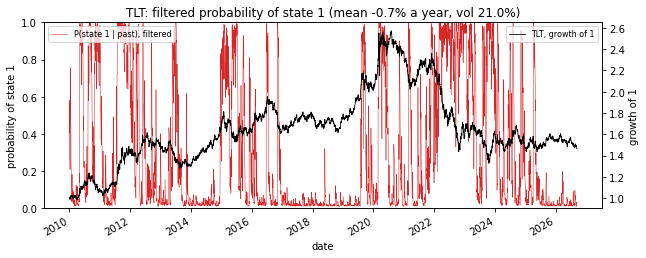

In [6]:
fig, ax = plt.subplots(figsize=(10, 3.8))
m2.regimes["state 1"].plot(ax=ax, lw=0.5, color="tab:red", label="P(state 1 | past), filtered")
ax.set_ylim(0, 1); ax.set_ylabel("probability of state 1")
ax2 = ax.twinx(); (1 + y).cumprod().plot(ax=ax2, color="black", lw=0.8, label="TLT, growth of 1"); ax2.set_ylabel("growth of 1")
ax.set_title(f"TLT: filtered probability of state 1 (mean {m2.mu[0] * 252:+.1%} a year, vol {m2.sigma[0] * np.sqrt(252):.1%})")
ax.legend(loc="upper left", fontsize=8); ax2.legend(loc="upper right", fontsize=8); plt.show()

## The residual layer

The one-step predictive distribution of the model on day $t$ is the mixture

$$
F_t(r) = \sum_{k=1}^{K} \eta_{t|t-1,k}\, \Phi\!\left(\frac{r - \mu_k}{\sigma_k}\right),
$$

and the Rosenblatt transform $U_t = F_t(r_t)$ is i.i.d. uniform on $(0, 1)$ when the model is right. `filter()` returns its normal score $\varepsilon_t = \Phi^{-1}(U_t)$, which is then i.i.d. $N(0, 1)$: the residual layer the C-vine sees, of the same kind as a GARCH's standardized residual. The three tests are applied to $\varepsilon_t$ with $m = 20$ lags: the Ljung-Box statistic on $\varepsilon_t$ and on $\varepsilon_t^2$,

$$
Q_m = n(n+2) \sum_{j=1}^{m} \frac{\hat\rho_j^{\,2}}{n - j} \;\sim\; \chi^2_m,
$$

with $\hat\rho_j$ the sample autocorrelation at lag $j$, and Engle's ARCH-LM test, $n R^2$ of the regression of $\varepsilon_t^2$ on its $m$ lags, also $\chi^2_m$. Read the p-values: the residuals show no autocorrelation, but their squares do, and the ARCH-LM test rejects. Two regimes with constant volatility inside each do not absorb the volatility clustering of daily Treasury returns; this is what the selector will hold against the HMM.

In [7]:
z = m2.filter()
pd.Series(iid_tests(z.values), name="p-value").round(3)

lb_z       0.133
lb_z2      0.000
arch_lm    0.000
Name: p-value, dtype: float64

Two pictures of the same residual layer: the histogram of the uniforms $U_t$, whose density should be flat at 1 if the model were right (a hump or a dip in the middle would say the predictive mixture is too wide or too narrow), and the time series of the normal scores $\varepsilon_t$, in which volatility clustering shows as bursts of large values.

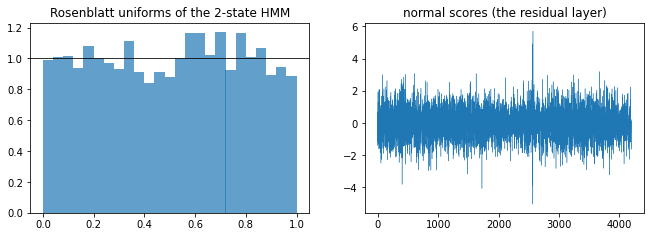

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].hist(m2.uniforms(), bins=25, density=True, color="tab:blue", alpha=0.7); axes[0].axhline(1, color="black", lw=0.8); axes[0].set_title("Rosenblatt uniforms of the 2-state HMM")
axes[1].plot(z.values, lw=0.4); axes[1].set_title("normal scores (the residual layer)"); plt.show()

## The bootstrap goodness-of-fit test

The Cramér-von Mises statistic of the uniforms against the uniform distribution is, with $U_{(1)} \le \dots \le U_{(n)}$ the sorted values,

$$
W^2 = \frac{1}{12 n} + \sum_{i=1}^{n} \left( U_{(i)} - \frac{i - 0.5}{n} \right)^2 .
$$

Its distribution under the fitted model is obtained by parametric bootstrap, as in GenHMM1d's `GofHMMGen`: for $b = 1, \dots, B$ ($B = 100$), simulate a series of length $n$ from the fitted chain, refit the model on it (warm-started at the fitted parameters), compute the Rosenblatt uniforms of the refit and their statistic $W^2_b$. The p-value is the share of bootstrap statistics above the observed one, $p = \frac{1}{B}\sum_b \mathbf 1\{W^2_b > W^2\}$. Both models are rejected here: with 4,197 days, the test has the power to see the clustering the residual tests found above.

In [9]:
t0 = time.time()
g2 = gof_bootstrap(m2, y, B=100, seed=0)
g3 = gof_bootstrap(m3, y, B=100, seed=0)
print(f"{time.time() - t0:.0f} s")
pd.DataFrame({"CvM statistic": [g2["stat"], g3["stat"]], "bootstrap p-value": [g2["pvalue"], g3["pvalue"]], "BIC": [m2.bic, m3.bic]},
             index=[m2.name, m3.name]).round(4)

2692 s


,CvM statistic,bootstrap p-value,BIC
HMM(2),0.2023,0.0,-27787.7229
HMM(3),0.2638,0.0,-27887.8005


## Against the GARCH family

`select_dynamics` runs the whole competition for this asset. The 28 candidates are: a constant or an AR(1) mean, $r_t = c + \varepsilon_t \sigma_t$ or $r_t = c + \phi r_{t-1} + \sigma_t \varepsilon_t$, with a constant variance or a GARCH, GJR or EGARCH variance of orders $p, q \in \{1, 2\}$ (2 means × (1 + 3 × 4) variance models = 26), plus the HMM with 2 and 3 regimes. Each is fitted by maximum likelihood with Gaussian innovations; its residual layer $\varepsilon_t$ is tested by the three tests above at the 5 percent level, and among the candidates that pass all three the one with the lowest $\mathrm{BIC} = k \ln n - 2\ell$ is kept (the GARCH log-likelihoods, computed on returns × 100, are put back on the data scale by $\ell + n \ln 100$ so that they compare with the HMM's). The bootstrap test is then run on the winner. For TLT the HMM candidates fail the ARCH tests and a Const-GARCH(1,1) wins; its own bootstrap p-value is 0 too, because Gaussian innovations cannot carry the fat tails of the standardized residuals. The generator does not rely on that assumption: the Johnson SU marginal of the residual layer is fitted to the residuals' skewness and kurtosis.

In [10]:
t0 = time.time()
ad = select_dynamics(y.to_frame(), gof=True, B=100, seed=0, verbose=False)
print(f"{time.time() - t0:.0f} s")
ad.report.T

79 s


asset,TLT
model,"Const-GARCH(1,1)"
mean,const
vol,garch
p,1
q,1
states,0
n_params,4
loglik,13984.604841
bic,-27935.841181
lb_z,0.269842


The candidate table, sorted by $\mathrm{BIC} = k \ln n - 2\ell$: `passed` is true when the three p-values exceed $\alpha = 0.05$. The winner is the first row with `passed` true; a lower BIC among the failing rows does not count, because a model whose residuals are not independent does not give an i.i.d. residual layer, which is what the vine needs.

In [11]:
c = ad.candidates
c.sort_values("bic")[["model", "n_params", "bic", "lb_z", "lb_z2", "arch_lm", "passed"]].head(8).round(3)

,model,n_params,bic,lb_z,lb_z2,arch_lm,passed
2,"Const-GARCH(1,1)",4,-27935.841,0.270,0.850,0.881,True
18,"Const-EGARCH(1,1)",4,-27930.555,0.260,0.342,0.431,True
10,"Const-GJR(1,1)",5,-27930.407,0.269,0.932,0.945,True
3,"Const-GARCH(1,2)",5,-27928.544,0.269,0.855,0.881,True
6,"AR(1)-GARCH(1,1)",5,-27927.632,0.594,0.855,0.885,True
4,"Const-GARCH(2,1)",5,-27927.499,0.270,0.850,0.881,True
20,"Const-EGARCH(2,1)",5,-27923.955,0.255,0.309,0.389,True
19,"Const-EGARCH(1,2)",5,-27923.161,0.258,0.333,0.415,True


## A simulated year

`unfilter` is the exact inverse of the filter, run from the last filtered probabilities $\eta_{n|n}$. For each simulated day $t = 1, \dots, 252$ and each path:

1. predictive weights $W_t = Q'\,\eta_{t-1|t-1}$;
2. the uniform $U_t = \Phi(\varepsilon_t)$ from the i.i.d. normal score, and the return $r_t = F_t^{-1}(U_t)$, the inverse of the mixture $F_t(r) = \sum_k W_{t,k}\,\Phi((r - \mu_k)/\sigma_k)$ found by bisection (the mixture is continuous and strictly increasing, so the inverse is unique);
3. the update $\eta_{t|t,k} \propto W_{t,k}\, \sigma_k^{-1}\phi((r_t - \mu_k)/\sigma_k)$.

Filtering the simulated path returns the normal scores to machine precision. Here the normal scores are drawn i.i.d. $N(0,1)$ directly; in a market they come from the vine. The figure shows five cumulative paths $\prod_{s \le t}(1 + r_s)$ after the last observed day, against the last observed year.

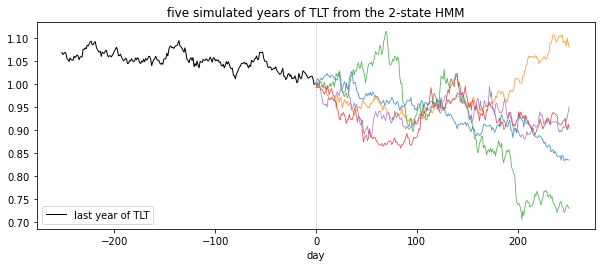

In [12]:
paths = m2.unfilter(np.random.default_rng(1).standard_normal((5, 252)))
hist = (1 + y.iloc[-252:]).cumprod()
fig, ax = plt.subplots(figsize=(10, 3.8))
ax.plot(np.arange(-252, 0), hist.values / hist.values[-1], color="black", lw=1, label="last year of TLT")
for k in range(5):
    ax.plot(np.arange(0, 252), np.cumprod(1 + paths[k]), lw=0.8, alpha=0.8)
ax.axvline(0, color="grey", lw=0.6, ls=":"); ax.set_xlabel("day"); ax.set_title("five simulated years of TLT from the 2-state HMM"); ax.legend(); plt.show()

## In a market

In `CVineMarket(..., dynamics='auto')` this model is one candidate per asset,
next to the GARCH family; `dynamics={'TLT': 'hmm(2)', ...}` imposes it. Notebook
07 runs the selection for four ETFs (the HMM with three regimes wins for the
commodity ETF) and simulates the paths.